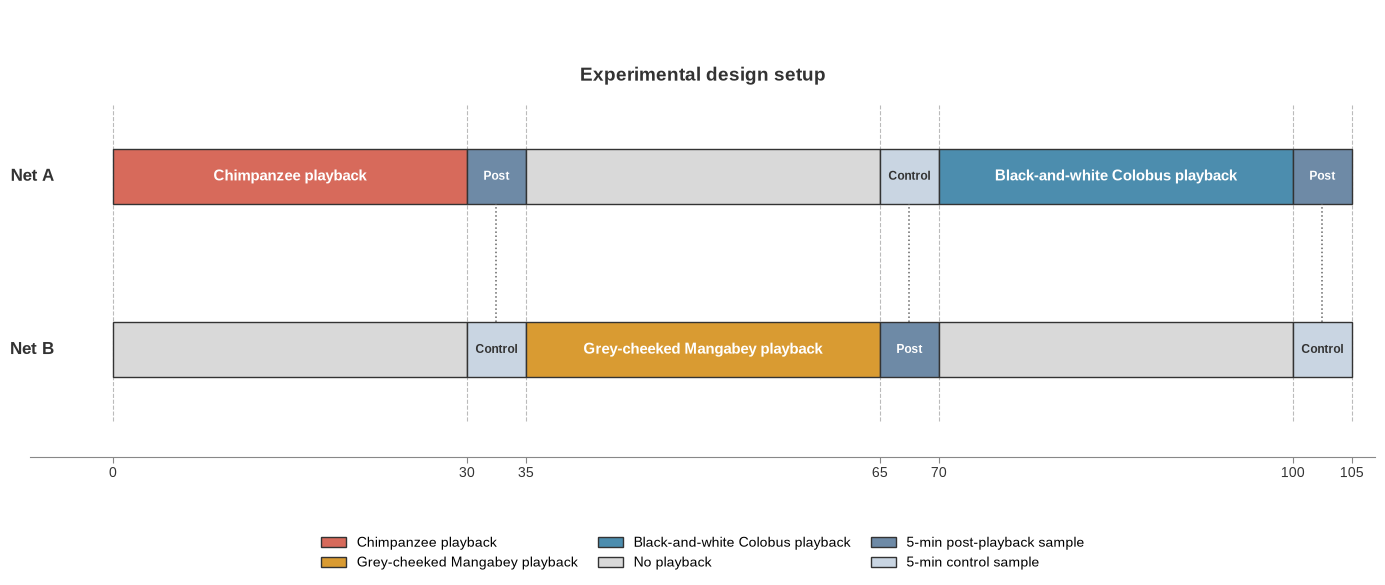

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

plt.rcParams["font.family"] = ["Liberation Sans", "sans-serif"]

# Colours

chimp_col = "#D76A5B"
mangabey_col = "#D99B32"
bw_colobus_col = "#4C8DAE"
red_colobus_col = "#6C9A62"   # kept for consistency, not used in this example

no_playback_col = "#D9D9D9"
post_window_col = "#6E8AA6"      # 5-min post-playback
control_window_col = "#C9D5E2"   # simultaneous 5-min control

edge_col = "#333333"
text_col = "#333333"
line_col = "#666666"

# Figure

fig, ax = plt.subplots(figsize=(14, 6))

# vertical positions
y_A = 2.3
y_B = 1.1
bar_h = 0.38

# Experimental periods
# 30-min playback period + following 5-min comparison window

# Period 1: CH playback at Net A
p1_start, p1_end = 0, 30
w1_start, w1_end = 30, 35

# Period 2: GM playback at Net B
p2_start, p2_end = 35, 65
w2_start, w2_end = 65, 70

# Period 3: BC playback at Net A
p3_start, p3_end = 70, 100
w3_start, w3_end = 100, 105


# Helper function

def draw_block(playback_net, playback_colour, playback_label,
               period_start, period_end, window_start, window_end):

    # playback at Net A
    if playback_net == "A":

        # playback period at Net A
        ax.add_patch(Rectangle(
            (period_start, y_A),
            period_end - period_start,
            bar_h,
            facecolor=playback_colour,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # no playback at Net B
        ax.add_patch(Rectangle(
            (period_start, y_B),
            period_end - period_start,
            bar_h,
            facecolor=no_playback_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # playback label
        ax.text(
            (period_start + period_end) / 2,
            y_A + bar_h / 2,
            playback_label,
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            fontweight="bold"
        )

        # 5-min post-playback sample
        ax.add_patch(Rectangle(
            (window_start, y_A),
            window_end - window_start,
            bar_h,
            facecolor=post_window_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # simultaneous 5-min control sample
        ax.add_patch(Rectangle(
            (window_start, y_B),
            window_end - window_start,
            bar_h,
            facecolor=control_window_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # labels for 5-min windows
        ax.text(
            (window_start + window_end) / 2,
            y_A + bar_h / 2,
            "Post",
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            fontweight="bold"
        )

        ax.text(
            (window_start + window_end) / 2,
            y_B + bar_h / 2,
            "Control",
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_col,
            fontweight="bold"
        )

    # playback at Net B
    if playback_net == "B":

        # no playback at Net A
        ax.add_patch(Rectangle(
            (period_start, y_A),
            period_end - period_start,
            bar_h,
            facecolor=no_playback_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # playback period at Net B
        ax.add_patch(Rectangle(
            (period_start, y_B),
            period_end - period_start,
            bar_h,
            facecolor=playback_colour,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # playback label
        ax.text(
            (period_start + period_end) / 2,
            y_B + bar_h / 2,
            playback_label,
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            fontweight="bold"
        )

        # simultaneous 5-min control sample
        ax.add_patch(Rectangle(
            (window_start, y_A),
            window_end - window_start,
            bar_h,
            facecolor=control_window_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # 5-min post-playback sample
        ax.add_patch(Rectangle(
            (window_start, y_B),
            window_end - window_start,
            bar_h,
            facecolor=post_window_col,
            edgecolor=edge_col,
            linewidth=1.0
        ))

        # labels for 5-min windows
        ax.text(
            (window_start + window_end) / 2,
            y_A + bar_h / 2,
            "Control",
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_col,
            fontweight="bold"
        )

        ax.text(
            (window_start + window_end) / 2,
            y_B + bar_h / 2,
            "Post",
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            fontweight="bold"
        )

    # dotted line linking matched 5-min windows
    x_mid = (window_start + window_end) / 2

    ax.plot(
        [x_mid, x_mid],
        [y_B + bar_h, y_A],
        linestyle=":",
        linewidth=1.1,
        color=line_col
    )
"""
    # playback label above each period
    ax.text(
        (period_start + period_end) / 2,
        3.35,
        playback_label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=text_col
    )
"""

# Draw periods

draw_block(
    "A",
    chimp_col,
    "Chimpanzee playback",
    p1_start, p1_end,
    w1_start, w1_end
)

draw_block(
    "B",
    mangabey_col,
    "Grey-cheeked Mangabey playback",
    p2_start, p2_end,
    w2_start, w2_end
)

draw_block(
    "A",
    bw_colobus_col,
    "Black-and-white Colobus playback",
    p3_start, p3_end,
    w3_start, w3_end
)

# Net labels

ax.text(
    -5,
    y_A + bar_h / 2,
    "Net A",
    ha="right",
    va="center",
    fontsize=12,
    fontweight="bold",
    color=text_col
)

ax.text(
    -5,
    y_B + bar_h / 2,
    "Net B",
    ha="right",
    va="center",
    fontsize=12,
    fontweight="bold",
    color=text_col
)

# Mark starts and ends of periods

period_marks = [0, 30, 35, 65, 70, 100, 105]

for x in period_marks:
    ax.axvline(
        x=x,
        ymin=0.08,
        ymax=0.785,
        color="#BBBBBB",
        linewidth=0.8,
        linestyle="--",
        zorder=0
    )

# Axes and style

ax.set_xlim(-7, 107)
ax.set_ylim(0.55, 3.65)

ax.set_xticks(period_marks)

ax.set_xticklabels(
    [str(x) for x in period_marks],
    fontsize=10,
    color=text_col
)

ax.set_yticks([])

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#888888")

ax.tick_params(
    axis="x",
    length=4,
    color="#888888"
)

ax.set_title(
    "Experimental design setup",
    fontsize=14,
    fontweight="bold",
    color=text_col,
    pad=0,
    y=0.84
)

# Legend

legend_handles = [
    Patch(
        facecolor=chimp_col,
        edgecolor=edge_col,
        label="Chimpanzee playback"
    ),
    Patch(
        facecolor=mangabey_col,
        edgecolor=edge_col,
        label="Grey-cheeked Mangabey playback"
    ),
    Patch(
        facecolor=bw_colobus_col,
        edgecolor=edge_col,
        label="Black-and-white Colobus playback"
    ),
    Patch(
        facecolor=no_playback_col,
        edgecolor=edge_col,
        label="No playback"
    ),
    Patch(
        facecolor=post_window_col,
        edgecolor=edge_col,
        label="5-min post-playback sample"
    ),
    Patch(
        facecolor=control_window_col,
        edgecolor=edge_col,
        label="5-min control sample"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=3,
    frameon=False,
    fontsize=9.8,
    handlelength=1.8,
    columnspacing=1.5
)

plt.tight_layout()

# Save

plt.savefig(
    "experimental_setup_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "experimental_setup_final.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()